# Recovery for NoInhibition model

Goal of this notebook:

1. Define a direct measurement model for:
   - $p_{\text{intention},A}$
   - $p_{\text{intention},B}$
   - $p_{\text{recall},X}$
   - $p_{\text{recall},Y}$

2. Use no-inhibition mDMC logic as basis for predicted accuracies.

3. Run simulation-based recovery using the real filtered denominators from the final fitting sample.

4. Summarize recovery quality using:
   - scatterplots of true vs recovered values
   - correlation
   - bias
   - RMSE

5. Fit the real sample only if recovery looks acceptable.

6. Compare observed vs predicted AX/AY/BX/BY accuracies in the real data.

This notebook does **not** yet fit the full process model with alpha / alphaAX / delta_t / lambda.
It focuses only on recoverability of the measurement-level probabilities.

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.special import expit
from scipy.stats import binom

## Load fitting sample

In [12]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

fit_path = project_root / "data" / "AXCPT_12yr_fitting_sample.csv"
fit_df = pd.read_csv(fit_path)

print("Loaded:", fit_path)
print("Shape:", fit_df.shape)
fit_df.head()

Loaded: /Users/yizj/Desktop/AX-CPT/metaControl_behavioral_Inhibition/data/AXCPT_12yr_fitting_sample.csv
Shape: (129, 41)


,ID,Completed_AX_CPT_12yr,acc_rej_12yr,AX_CPT_Notes_12yr,Mean_RT_12yr,Std_pop_12yr,Std_3_12yr,Lo_Std_12yr,Hi_Std_12yr,AX_Count_12yr,...,PBSI_RT_12yr,PBSI_SUM_12yr,dprime_context_12yr,A_Cue_Bias_12yr,A_Cue_Bias_Check,AY_False_Alarm,has_all_counts,has_all_acc_counts,model_usable,has_any_core
0,6018.0,1.0,1.0,NaN,450.33,127.57,382.71,67.62,833.04,105.0,...,0.174679,0.362179,0.498652,0.342373,0.342373,0.642857,True,True,True,True
1,6029.0,1.0,1.0,NaN,556.35,177.39,532.17,24.18,1088.52,105.0,...,0.318952,0.718952,3.119669,0.431398,0.431398,0.214286,True,True,True,True
2,6038.0,1.0,1.0,NaN,469.03,162.78,488.34,-19.31,957.37,105.0,...,0.197544,0.165286,1.382736,-0.125262,-0.125262,0.200000,True,True,True,True
3,6040.0,1.0,1.0,NaN,409.18,160.49,481.47,-72.29,890.65,105.0,...,0.285968,1.013241,2.562589,0.657425,0.657425,0.600000,True,True,True,True
4,6043.0,1.0,1.0,NaN,427.63,122.07,366.21,61.42,793.84,105.0,...,0.130951,0.276714,1.734510,0.603612,0.603612,0.461538,True,True,True,True


## Define trial-type columns and design constants

Use the fitting sample's filtered denominators and correct counts.

Fixed settings:
- trial-type proportions to the intended design: 70/10/10/10
- load = 1 (assuming standard single A-cue version)
- recall accuracy scaling parameter `m`
- slip probability `p_slip`

These fixed settings should be revisited later in sensitivity analyses if needed.

In [38]:
TRIAL_TYPES = ["AX", "AY", "BX", "BY"]

count_cols = [
    "AX_Count_Filtered_12yr",
    "AY_Count_Filtered_12yr",
    "BX_Count_Filtered_12yr",
    "BY_Count_Filtered_12yr",
]

acc_count_cols = [
    "AX_Acc_Count_12yr",
    "AY_Acc_Count_12yr",
    "BX_Acc_Count_12yr",
    "BY_Acc_Count_12yr",
]

acc_rate_cols = [
    "AX_Acc_12yr",
    "AY_Acc_12yr",
    "BX_Acc_12yr",
    "BY_Acc_12yr",
]

p_cue_probe = np.array([0.70, 0.10, 0.10, 0.10], dtype=float)

# provisional fixed assumptions for measurement-model recovery
load = 1
m = 1

print("Using p_cue_probe =", p_cue_probe)
print("Using load =", load, "m =", m)

Using p_cue_probe = [0.7 0.1 0.1 0.1]
Using load = 1 m = 1


In [39]:
p_slip = 1 - fit_df["BY_Acc_12yr"].mean()
print("Sample-specific slip estimate:", p_slip)

Sample-specific slip estimate: 0.15375528863900956


# 4-parameter No-inhibition Recovery

## Helpers

- *habit* accuracy by trial type
- *proactive* accuracy by trial type
- *recall* accuracy by trial type
- predicted trial-type accuracies given:
  - $p_{\text{intention},A}$
  - $p_{\text{intention},B}$
  - $p_{\text{recall},X}$
  - $p_{\text{recall},Y}$

> Intention depends on cue (A vs B); recall depends on probe (X vs Y)

In [40]:
def compute_component_accuracies(p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0):
    """
    Returns habit, proactive, and recall accuracies for trial types
    [AX, AY, BX, BY].
    """
    pAX, pAY, pBX, pBY = p_cue_probe

    # Habitual accuracy
    # For X probes, habit follows the marginal AX/BX frequency under X
    # For Y probes, habitual responding is effectively "not AX"
    p_correct_habit = np.array([
        pAX / (pAX + pBX),   # AX
        1.0,                 # AY
        pBX / (pAX + pBX),   # BX
        1.0                  # BY
    ], dtype=float)

    # Proactive accuracy under no-inhibition logic
    proactive_base = np.array([
        pAX / (pAX + pAY),         # AX
        1.0 - pAX / (pAX + pAY),   # AY
        1.0,                       # BX
        1.0                        # BY
    ], dtype=float)

    proactive_base = proactive_base * (1.0 - lambda_ * (load - 1))

    # Recall accuracy
    recall_base = np.full(4, m * (1.0 - lambda_ * (load - 1)), dtype=float)

    # Apply slip
    def apply_slip(p):
        return p * (1 - p_slip) + (1 - p) * p_slip

    p_correct_habit = apply_slip(p_correct_habit)
    p_correct_proactive = apply_slip(proactive_base)
    p_correct_recall = apply_slip(recall_base)

    return p_correct_habit, p_correct_proactive, p_correct_recall

In [41]:
def predict_accuracies_measurement(params, p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0):
    """
    params = [p_int_A, p_int_B, p_rec_X, p_rec_Y]
    returns predicted accuracies for [AX, AY, BX, BY]
    """
    p_int_A, p_int_B, p_rec_X, p_rec_Y = params

    p_habit, p_pro, p_rec = compute_component_accuracies(
        p_cue_probe=p_cue_probe,
        load=load,
        m=m,
        p_slip=p_slip,
        lambda_=lambda_
    )

    preds = np.zeros(4)

    # AX: A cue, X probe
    preds[0] = (
        p_int_A * p_pro[0]
        + (1 - p_int_A) * (p_rec_X * p_rec[0] + (1 - p_rec_X) * p_habit[0])
    )

    # AY: A cue, Y probe
    preds[1] = (
        p_int_A * p_pro[1]
        + (1 - p_int_A) * (p_rec_Y * p_rec[1] + (1 - p_rec_Y) * p_habit[1])
    )

    # BX: B cue, X probe
    preds[2] = (
        p_int_B * p_pro[2]
        + (1 - p_int_B) * (p_rec_X * p_rec[2] + (1 - p_rec_X) * p_habit[2])
    )

    # BY: B cue, Y probe
    preds[3] = (
        p_int_B * p_pro[3]
        + (1 - p_int_B) * (p_rec_Y * p_rec[3] + (1 - p_rec_Y) * p_habit[3])
    )

    return np.clip(preds, 1e-8, 1 - 1e-8)

## Binomial negative log-likelihood

For each participant, the data are:
- 4 denominators
- 4 correct counts

The participant likelihood is the product of 4 binomial terms, one for each trial type.

In [42]:
def neg_loglik_measurement(params, n_trials, n_correct, p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0):
    preds = predict_accuracies_measurement(
        params,
        p_cue_probe=p_cue_probe,
        load=load,
        m=m,
        p_slip=p_slip,
        lambda_=lambda_
    )

    # robust clipping
    preds = np.clip(preds, 1e-8, 1 - 1e-8)

    ll = binom.logpmf(n_correct.astype(int), n_trials.astype(int), preds).sum()
    return -ll

# Recovery simulation

Test recoverability using the **real filtered denominators** from the sample.

For each simulated participant:
- use that participant's real AX/AY/BX/BY denominators,
- sample true latent values,
- generate correct counts from the binomial model,
- refit the same model,
- compare true vs recovered values.

In [43]:
fit_counts = fit_df[count_cols].to_numpy(dtype=int)

print("Number of real participants used as denominator templates:", fit_counts.shape[0])
print("First 3 denominator rows:")
fit_counts[:3]

Number of real participants used as denominator templates: 129
First 3 denominator rows:


array([[104,  14,  14,  14],
       [102,  14,  14,  13],
       [101,  15,  14,  15]])

## Simulation ranges

These ranges are intentionally broad.

In [44]:
def sample_true_params(rng):
    """
    Sample plausible true values for:
    [p_int_A, p_int_B, p_rec_X, p_rec_Y]
    """
    p_int_A = rng.uniform(0.05, 0.70)
    p_int_B = rng.uniform(0.30, 0.98)
    p_rec_X = rng.uniform(0.40, 0.98)
    p_rec_Y = rng.uniform(0.20, 0.95)
    return np.array([p_int_A, p_int_B, p_rec_X, p_rec_Y], dtype=float)

## Simulate and recover for all denominator templates

In [45]:
def run_recovery_simulation(fit_counts, p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0, seed=2026):
    rng = np.random.default_rng(seed)

    records = []

    for i in range(fit_counts.shape[0]):
        n_trials = fit_counts[i].copy()
        true_params = sample_true_params(rng)

        true_accs = predict_accuracies_measurement(
            true_params,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_
        )

        n_correct = rng.binomial(n_trials, true_accs)

        fit_res = fit_one_participant_measurement(
            n_trials=n_trials,
            n_correct=n_correct,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_,
            n_starts=30,
            seed=int(rng.integers(1, 10_000_000))
        )

        est_params = fit_res["params"]

        records.append({
            "sim_id": i,
            "n_total": int(n_trials.sum()),
            "true_p_int_A": true_params[0],
            "true_p_int_B": true_params[1],
            "true_p_rec_X": true_params[2],
            "true_p_rec_Y": true_params[3],
            "est_p_int_A": est_params[0],
            "est_p_int_B": est_params[1],
            "est_p_rec_X": est_params[2],
            "est_p_rec_Y": est_params[3],
            "fit_success": fit_res["success"],
            "nll": fit_res["fun"]
        })

    return pd.DataFrame(records)

In [46]:
recovery_df = run_recovery_simulation(
    fit_counts=fit_counts,
    p_cue_probe=p_cue_probe,
    load=load,
    m=m,
    p_slip=p_slip,
    lambda_=0.0,
    seed=2026
)

print("Recovery simulations:", recovery_df.shape)
recovery_df.head()

Recovery simulations: (129, 12)


,sim_id,n_total,true_p_int_A,true_p_int_B,true_p_rec_X,true_p_rec_Y,est_p_int_A,est_p_int_B,est_p_rec_X,est_p_rec_Y,fit_success,nll
0,0,146,0.166308,0.735141,0.671016,0.477875,0.293939,0.000000,0.706061,0.177734,True,6.959658
1,1,143,0.243897,0.957534,0.933513,0.676903,0.217780,0.796729,0.508554,0.337843,True,6.398592
2,2,145,0.270228,0.488971,0.531273,0.594363,0.296368,1.000000,0.694445,0.302515,True,6.515960
3,3,148,0.177008,0.704509,0.652482,0.424994,0.345075,0.000000,0.752453,0.786305,True,7.082521
4,4,143,0.274315,0.943837,0.726759,0.524572,0.127101,0.841162,0.000000,0.635809,True,6.519192


## Summarize recovery
- correlation
- bias
- RMSE
for each recovered quantity.

In [47]:
def recovery_metrics(df, true_col, est_col):
    x = df[true_col].to_numpy()
    y = df[est_col].to_numpy()

    corr = np.corrcoef(x, y)[0, 1]
    bias = np.mean(y - x)
    rmse = np.sqrt(np.mean((y - x) ** 2))

    return pd.Series({
        "correlation": corr,
        "bias": bias,
        "rmse": rmse
    })

metrics_table = pd.DataFrame({
    "p_int_A": recovery_metrics(recovery_df, "true_p_int_A", "est_p_int_A"),
    "p_int_B": recovery_metrics(recovery_df, "true_p_int_B", "est_p_int_B"),
    "p_rec_X": recovery_metrics(recovery_df, "true_p_rec_X", "est_p_rec_X"),
    "p_rec_Y": recovery_metrics(recovery_df, "true_p_rec_Y", "est_p_rec_Y"),
}).T

metrics_table

,correlation,bias,rmse
p_int_A,0.722469,0.024965,0.184647
p_int_B,0.332611,-0.078683,0.412411
p_rec_X,0.317810,-0.157247,0.390003
p_rec_Y,0.070778,-0.064016,0.343130


## Scatterplots: true vs recovered

The diagonal line is perfect recovery.

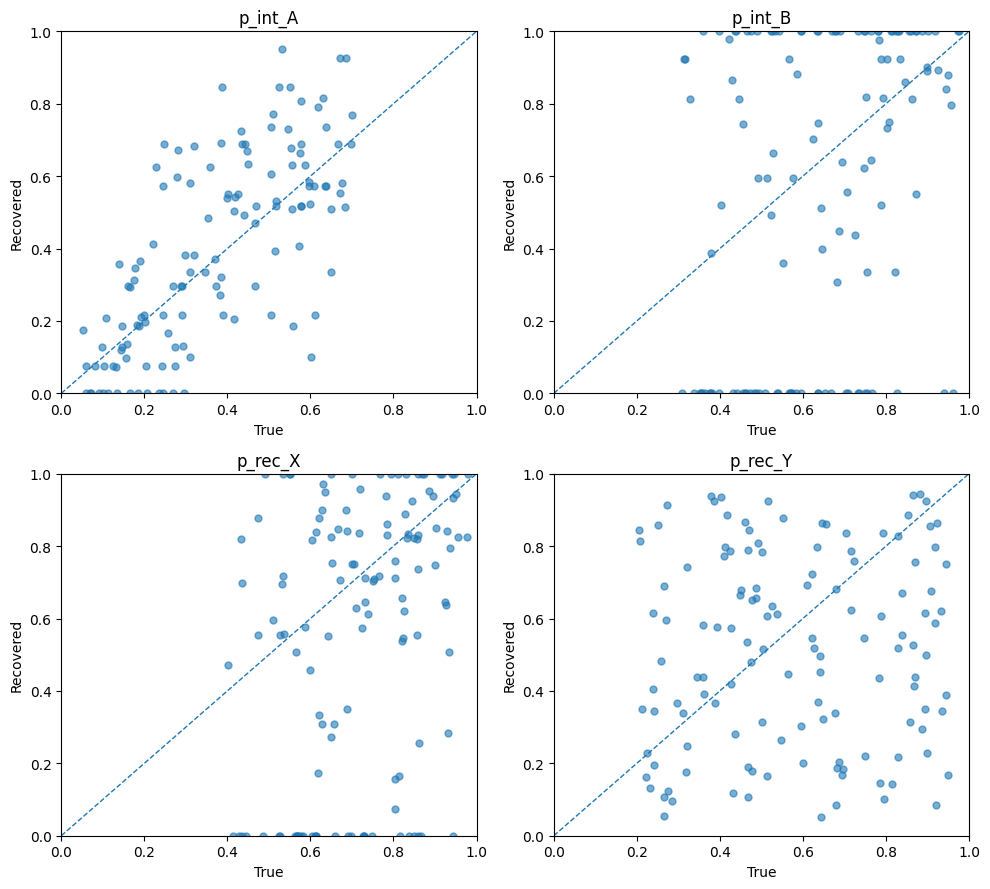

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

pairs = [
    ("true_p_int_A", "est_p_int_A", "p_int_A"),
    ("true_p_int_B", "est_p_int_B", "p_int_B"),
    ("true_p_rec_X", "est_p_rec_X", "p_rec_X"),
    ("true_p_rec_Y", "est_p_rec_Y", "p_rec_Y"),
]

for ax, (tcol, ecol, title) in zip(axes.ravel(), pairs):
    ax.scatter(recovery_df[tcol], recovery_df[ecol], alpha=0.6, s=25)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("True")
    ax.set_ylabel("Recovered")
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [49]:
for col in ["est_p_int_A", "est_p_int_B", "est_p_rec_X", "est_p_rec_Y"]:
    print(col)
    print("near 0:", (recovery_df[col] < 0.05).sum())
    print("near 1:", (recovery_df[col] > 0.95).sum())
    print()

est_p_int_A
near 0: 14
near 1: 1

est_p_int_B
near 0: 42
near 1: 41

est_p_rec_X
near 0: 31
near 1: 22

est_p_rec_Y
near 0: 0
near 1: 0



## Interpretation 
Why many estimates near both 0 and 1:
- `p_int_B` and `p_rec_X` are behaving like competing explanations for the same observed data
- The model cannot tell whether good performance on **B-cue** and **X-probe** trials came from:
    - strong proactive intention at cue B, or
	- successful recall at probe X
- the optimizer can often fit the same AX/AY/BX/BY summaries by sending one high and the other low, or vice versa

# 2-parameter No-inhibition Recovery

Simplify the latent structure to:

- one global $p_{\text{intention}}$
- one global $p_{\text{recall}}$

This is a more conservative model than the 4-parameter cue/probe-specific version.

Rationale:
- each participant contributes only 4 observed AX-CPT summary cells (AX, AY, BX, BY),
- the 4-parameter version showed weak recoverability for several quantities,
- a 2-parameter version may be more stable and interpretable for this participant-summary dataset.

The structural assumptions remain the same:
- no inhibition
- same component accuracies for habit / proactive / recall
- same filtered denominators
- same binomial likelihood setup

In [50]:
def predict_accuracies_measurement_2param(params, p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0):
    """
    params = [p_intention, p_recall]
    returns predicted accuracies for [AX, AY, BX, BY]
    """
    p_int, p_rec_global = params

    p_habit, p_pro, p_rec = compute_component_accuracies(
        p_cue_probe=p_cue_probe,
        load=load,
        m=m,
        p_slip=p_slip,
        lambda_=lambda_
    )

    preds = np.zeros(4)

    # Same p_intention for all trial types
    # Same p_recall for all trial types
    for s in range(4):
        preds[s] = (
            p_int * p_pro[s]
            + (1 - p_int) * (p_rec_global * p_rec[s] + (1 - p_rec_global) * p_habit[s])
        )

    return np.clip(preds, 1e-8, 1 - 1e-8)

## Binomial negative log-likelihood for 2-parameter model

For each participant, the likelihood is again the product of 4 binomial terms,
but now the predicted probabilities are generated from only 2 latent parameters.

In [52]:
def neg_loglik_measurement_2param(params, n_trials, n_correct, p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0):
    preds = predict_accuracies_measurement_2param(
        params,
        p_cue_probe=p_cue_probe,
        load=load,
        m=m,
        p_slip=p_slip,
        lambda_=lambda_
    )

    preds = np.clip(preds, 1e-8, 1 - 1e-8)
    ll = binom.logpmf(n_correct.astype(int), n_trials.astype(int), preds).sum()
    return -ll

## Simulation ranges

In [53]:
def sample_true_params_2param(rng):
    """
    Sample plausible true values for:
    [p_intention, p_recall]
    """
    p_int = rng.uniform(0.05, 0.95)
    p_rec = rng.uniform(0.05, 0.95)
    return np.array([p_int, p_rec], dtype=float)

## Simulate and recover for all denominator templates

For each simulated participant:
- use the real filtered denominators from the fitting sample,
- sample true values of $p_{\text{intention}}$ and $p_{\text{recall}}$,
- generate correct counts from the binomial model,
- refit the same 2-parameter model,
- compare true vs recovered values.

### What “real filtered denominators” means

Each retained participant in the final fitting sample contributes four observed trial-type counts:

- `AX_Count_Filtered_12yr`
- `AY_Count_Filtered_12yr`
- `BX_Count_Filtered_12yr`
- `BY_Count_Filtered_12yr`

These are the **filtered denominators**. They are called denominators because, for each trial type, they are the number of usable trials out of which the number correct is counted.

For example, if a participant has:

- AX filtered count = 104
- AY filtered count = 14
- BX filtered count = 14
- BY filtered count = 14

then their observed accuracies are based on:

- 104 AX opportunities
- 14 AY opportunities
- 14 BX opportunities
- 14 BY opportunities

In the recovery simulation,use these filtered counts from the real dataset as the trial counts for simulated participants, rather than using equal counts.

### What the “true values” of $p_{\text{intention}}$ and $p_{\text{recall}}$ are

The “true values” are **not observed from the data**. They are simulated latent values choosen first, then try to recover from synthetic data.

These are **sampled from prespecified ranges** using a random number generator.

- $p_{\text{intention}} \sim \text{Uniform}(0.05, 0.95)$
- $p_{\text{recall}} \sim \text{Uniform}(0.05, 0.95)$

For each simulated participant, draw one value for intention and one value for recall from those intervals.

### Where the binomial model enters

The binomial model appears in the recovery simulation at the step where we generate synthetic correct-count data from:

- real filtered trial counts, and
- sampled latent parameters

1. Use the true $p_{\text{intention}}$ and $p_{\text{recall}}$ to compute **predicted accuracy probabilities** for AX, AY, BX, and BY.
2. For each trial type, treat the number correct as a **binomial random variable**:
   $$
   K_s \sim \text{Binomial}(N_s, \pi_s)
   $$
   where:
   - $N_s$ is the filtered count for trial type $s$,
   - $\pi_s$ is the model-predicted probability of a correct response for that trial type,
   - $K_s$ is the simulated number correct.

This is **generative** because it creates synthetic observed data from assumed latent parameters.

- In code: `n_correct = rng.binomial(n_trials, true_accs)`

Later, during fitting, the same binomial model is used in reverse: given the observed counts and correct counts, the optimizer searches for the parameter values that make the observed data most likely.

In [61]:
def fit_one_participant_measurement_2param(n_trials, n_correct, p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0, n_starts=20, seed=123):
    rng = np.random.default_rng(seed)
    bounds = [(0.0, 1.0)] * 2

    best_res = None

    for _ in range(n_starts):
        x0 = rng.uniform(0.05, 0.95, size=2)

        res = minimize(
            neg_loglik_measurement_2param,
            x0=x0,
            args=(n_trials, n_correct, p_cue_probe, load, m, p_slip, lambda_),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if best_res is None or res.fun < best_res.fun:
            best_res = res

    est = best_res.x
    preds = predict_accuracies_measurement_2param(
        est,
        p_cue_probe=p_cue_probe,
        load=load,
        m=m,
        p_slip=p_slip,
        lambda_=lambda_
    )

    return {
        "success": best_res.success,
        "fun": best_res.fun,
        "params": est,
        "preds": preds,
        "message": best_res.message
    }

In [62]:
def run_recovery_simulation_2param(fit_counts, p_cue_probe, load=1, m=1.0, p_slip=0.0, lambda_=0.0, seed=2026):
    rng = np.random.default_rng(seed)

    records = []

    for i in range(fit_counts.shape[0]):
        n_trials = fit_counts[i].copy()
        true_params = sample_true_params_2param(rng)

        true_accs = predict_accuracies_measurement_2param(
            true_params,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_
        )

        n_correct = rng.binomial(n_trials, true_accs)

        fit_res = fit_one_participant_measurement_2param(
            n_trials=n_trials,
            n_correct=n_correct,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_,
            n_starts=30,
            seed=int(rng.integers(1, 10_000_000))
        )

        est_params = fit_res["params"]

        records.append({
            "sim_id": i,
            "n_total": int(n_trials.sum()),
            "true_p_intention": true_params[0],
            "true_p_recall": true_params[1],
            "est_p_intention": est_params[0],
            "est_p_recall": est_params[1],
            "fit_success": fit_res["success"],
            "nll": fit_res["fun"]
        })

    return pd.DataFrame(records)

In [63]:
recovery_df_2p = run_recovery_simulation_2param(
    fit_counts=fit_counts,
    p_cue_probe=p_cue_probe,
    load=load,
    m=m,
    p_slip=p_slip,
    lambda_=0.0,
    seed=2026
)

print("2-parameter recovery simulations:", recovery_df_2p.shape)
recovery_df_2p.head()

2-parameter recovery simulations: (129, 8)


,sim_id,n_total,true_p_intention,true_p_recall,est_p_intention,est_p_recall,fit_success,nll
0,0,146,0.211041,0.625922,0.116049,0.731666,True,6.745123
1,1,143,0.209618,0.637506,0.443638,0.202608,True,7.856708
2,2,145,0.727459,0.513638,0.799458,0.230597,True,7.220688
3,3,148,0.523235,0.437821,0.169049,0.645856,True,7.460000
4,4,143,0.225858,0.585379,0.149568,0.782997,True,7.331761


## Summarize recovery 
- correlation
- bias
- RMSE

In [58]:
metrics_table_2p = pd.DataFrame({
    "p_intention": recovery_metrics(recovery_df_2p, "true_p_intention", "est_p_intention"),
    "p_recall": recovery_metrics(recovery_df_2p, "true_p_recall", "est_p_recall"),
}).T

metrics_table_2p

,correlation,bias,rmse
p_intention,0.811226,-0.040429,0.176802
p_recall,0.540783,-0.008460,0.324286


## Scatterplots: true vs recovered (2-parameter model)

The diagonal line is perfect recovery.

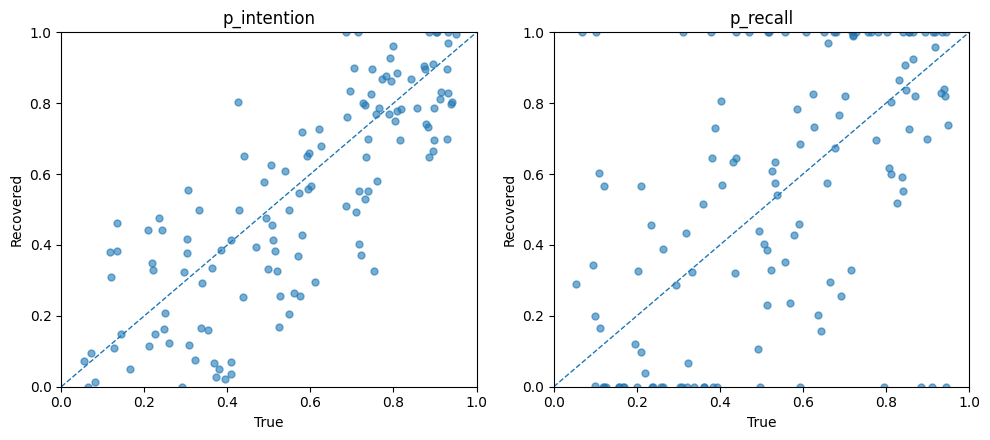

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

pairs_2p = [
    ("true_p_intention", "est_p_intention", "p_intention"),
    ("true_p_recall", "est_p_recall", "p_recall"),
]

for ax, (tcol, ecol, title) in zip(axes.ravel(), pairs_2p):
    ax.scatter(recovery_df_2p[tcol], recovery_df_2p[ecol], alpha=0.6, s=25)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("True")
    ax.set_ylabel("Recovered")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Boundary diagnostics

Check whether estimates collapse near 0 or 1.

In [60]:
for col in ["est_p_intention", "est_p_recall"]:
    print(col)
    print("near 0:", (recovery_df_2p[col] < 0.05).sum())
    print("near 1:", (recovery_df_2p[col] > 0.95).sum())
    print()

est_p_intention
near 0: 8
near 1: 9

est_p_recall
near 0: 28
near 1: 32



# Recovery map for the 2-parameter model

Previous simulation sampled true values randomly across the parameter space.

This section instead evaluates recovery on a structured 2D grid over:

- $p_{\text{intention}}$
- $p_{\text{recall}}$

At each grid point:

1. fix the true values to that $(p_{\text{intention}}, p_{\text{recall}})$ pair,
2. simulate many synthetic datasets using the **real filtered denominators** from the retained sample,
3. refit the same 2-parameter model,
4. summarize recovery quality.

This gives a map of:

- where recovery is stable,
- where recovery is biased or noisy,
- where estimates tend to collapse toward 0 or 1.

## Grid settings

In [68]:
grid_n = 10
n_reps_per_grid = 30
boundary_low = 0.05
boundary_high = 0.95

p_int_grid = np.linspace(0.05, 0.95, grid_n)
p_rec_grid = np.linspace(0.05, 0.95, grid_n)

print("Grid points for p_intention:", p_int_grid)
print("Grid points for p_recall:", p_rec_grid)
print("Replicates per grid point:", n_reps_per_grid)

Grid points for p_intention: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Grid points for p_recall: [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
Replicates per grid point: 30


## Helper: simulate and refit at one fixed grid point

For one fixed pair of true values,

$$
(p_{\text{intention}}^{\text{true}},\; p_{\text{recall}}^{\text{true}})
$$

Repeatedly:

1. generate synthetic correct counts from the binomial model,
2. refit the 2-parameter model,
3. store the recovered estimates.

This gives an empirical distribution of recovered values at that location in parameter space.

In [69]:
def run_gridpoint_recovery_2param(
    true_p_intention,
    true_p_recall,
    fit_counts,
    p_cue_probe,
    load=1,
    m=1.0,
    p_slip=0.0,
    lambda_=0.0,
    n_reps=30,
    seed=2026
):
    rng = np.random.default_rng(seed)

    true_params = np.array([true_p_intention, true_p_recall], dtype=float)
    recovered = []

    for rep in range(n_reps):
        # sample one denominator template from the real retained sample
        idx = rng.integers(0, fit_counts.shape[0])
        n_trials = fit_counts[idx].copy()

        true_accs = predict_accuracies_measurement_2param(
            true_params,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_
        )

        # generative binomial step
        n_correct = rng.binomial(n_trials, true_accs)

        fit_res = fit_one_participant_measurement_2param(
            n_trials=n_trials,
            n_correct=n_correct,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=lambda_,
            n_starts=30,
            seed=int(rng.integers(1, 10_000_000))
        )

        est_p_intention, est_p_recall = fit_res["params"]

        recovered.append({
            "true_p_intention": true_p_intention,
            "true_p_recall": true_p_recall,
            "est_p_intention": est_p_intention,
            "est_p_recall": est_p_recall,
            "fit_success": fit_res["success"],
            "nll": fit_res["fun"]
        })

    return pd.DataFrame(recovered)

## Helper: summarize recovery at one grid point

For each fixed true parameter pair, summarize:

For $p_{\text{intention}}$:
- mean recovered value,
- bias,
- RMSE,
- proportion of recovered estimates $< 0.05$,
- proportion of recovered estimates $> 0.95$.

The same quantities are computed for $p_{\text{recall}}$.

In [70]:
def summarize_gridpoint_recovery_2param(df_grid, low=0.05, high=0.95):
    out = {
        "true_p_intention": df_grid["true_p_intention"].iloc[0],
        "true_p_recall": df_grid["true_p_recall"].iloc[0],
        "n_reps": len(df_grid),
        "fit_success_rate": df_grid["fit_success"].mean(),

        "mean_est_p_intention": df_grid["est_p_intention"].mean(),
        "bias_p_intention": (df_grid["est_p_intention"] - df_grid["true_p_intention"]).mean(),
        "rmse_p_intention": np.sqrt(np.mean((df_grid["est_p_intention"] - df_grid["true_p_intention"])**2)),
        "prop_low_p_intention": (df_grid["est_p_intention"] < low).mean(),
        "prop_high_p_intention": (df_grid["est_p_intention"] > high).mean(),

        "mean_est_p_recall": df_grid["est_p_recall"].mean(),
        "bias_p_recall": (df_grid["est_p_recall"] - df_grid["true_p_recall"]).mean(),
        "rmse_p_recall": np.sqrt(np.mean((df_grid["est_p_recall"] - df_grid["true_p_recall"])**2)),
        "prop_low_p_recall": (df_grid["est_p_recall"] < low).mean(),
        "prop_high_p_recall": (df_grid["est_p_recall"] > high).mean(),
    }
    return out

## Run the full grid recovery map

In [71]:
grid_records = []

total_jobs = len(p_int_grid) * len(p_rec_grid)
job_counter = 0

for true_p_intention in p_int_grid:
    for true_p_recall in p_rec_grid:
        job_counter += 1
        print(f"Running grid point {job_counter}/{total_jobs}: "
              f"p_int={true_p_intention:.2f}, p_rec={true_p_recall:.2f}")

        df_grid = run_gridpoint_recovery_2param(
            true_p_intention=true_p_intention,
            true_p_recall=true_p_recall,
            fit_counts=fit_counts,
            p_cue_probe=p_cue_probe,
            load=load,
            m=m,
            p_slip=p_slip,
            lambda_=0.0,
            n_reps=n_reps_per_grid,
            seed=2026 + job_counter
        )

        grid_records.append(summarize_gridpoint_recovery_2param(
            df_grid,
            low=boundary_low,
            high=boundary_high
        ))

grid_summary_2p = pd.DataFrame(grid_records)
print("Done.")
grid_summary_2p.head()

Running grid point 1/100: p_int=0.05, p_rec=0.05
Running grid point 2/100: p_int=0.05, p_rec=0.15
Running grid point 3/100: p_int=0.05, p_rec=0.25
Running grid point 4/100: p_int=0.05, p_rec=0.35
Running grid point 5/100: p_int=0.05, p_rec=0.45
Running grid point 6/100: p_int=0.05, p_rec=0.55
Running grid point 7/100: p_int=0.05, p_rec=0.65
Running grid point 8/100: p_int=0.05, p_rec=0.75
Running grid point 9/100: p_int=0.05, p_rec=0.85
Running grid point 10/100: p_int=0.05, p_rec=0.95
Running grid point 11/100: p_int=0.15, p_rec=0.05
Running grid point 12/100: p_int=0.15, p_rec=0.15
Running grid point 13/100: p_int=0.15, p_rec=0.25
Running grid point 14/100: p_int=0.15, p_rec=0.35
Running grid point 15/100: p_int=0.15, p_rec=0.45
Running grid point 16/100: p_int=0.15, p_rec=0.55
Running grid point 17/100: p_int=0.15, p_rec=0.65
Running grid point 18/100: p_int=0.15, p_rec=0.75
Running grid point 19/100: p_int=0.15, p_rec=0.85
Running grid point 20/100: p_int=0.15, p_rec=0.95
Running g

,true_p_intention,true_p_recall,n_reps,fit_success_rate,mean_est_p_intention,bias_p_intention,rmse_p_intention,prop_low_p_intention,prop_high_p_intention,mean_est_p_recall,bias_p_recall,rmse_p_recall,prop_low_p_recall,prop_high_p_recall
0,0.05,0.05,30,1.0,0.045037,-0.004963,0.067492,0.666667,0.0,0.092960,0.042960,0.140291,0.533333,0.0
1,0.05,0.15,30,1.0,0.080490,0.030490,0.111851,0.600000,0.0,0.129152,-0.020848,0.143940,0.433333,0.0
2,0.05,0.25,30,1.0,0.091653,0.041653,0.110246,0.433333,0.0,0.261304,0.011304,0.229324,0.266667,0.0
3,0.05,0.35,30,1.0,0.105636,0.055636,0.121005,0.433333,0.0,0.259357,-0.090643,0.190423,0.133333,0.0
4,0.05,0.45,30,1.0,0.089020,0.039020,0.112703,0.533333,0.0,0.447412,-0.002588,0.196255,0.033333,0.0


## Helper: convert grid summaries into heatmap matrices

To plot heatmaps, reshape each summary metric into a matrix whose axes are:

- x-axis: true $p_{\text{recall}}$
- y-axis: true $p_{\text{intention}}$

In [74]:
def make_heatmap_matrix(df, value_col, p_int_grid, p_rec_grid):
    mat = (
        df.pivot(index="true_p_intention", columns="true_p_recall", values=value_col)
          .reindex(index=p_int_grid, columns=p_rec_grid)
          .to_numpy()
    )
    return mat

## Plot recovery heatmaps

Each row of the grid summary corresponds to one fixed pair of true values:

$$
\left(p_{\text{intention}}^{\text{true}},\; p_{\text{recall}}^{\text{true}}\right)
$$

At that grid point:

1. fixes the true latent values to that pair,
2. simulates many synthetic datasets using the real filtered denominators,
3. refits the same 2-parameter model to each synthetic dataset,
4. summarizes how the recovered estimates behave across repetitions.

### Mean recovered $p_{\text{intention}}$ and mean recovered $p_{\text{recall}}$

The average of recovered estimates across all replicates.

For example, if the true value is:

$$
p_{\text{intention}}^{\text{true}} = 0.05
$$

and the mean recovered value is:

$$
\overline{\hat p_{\text{intention}}} = 0.09,
$$

then the fitting procedure tends, on average, to estimate a value around 0.09 when the truth is 0.05.

### Bias

Bias measures whether the recovered estimates are systematically too high or too low, on average.

For a parameter $\theta$, bias is:

$$
\text{Bias} = \mathbb{E}[\hat\theta - \theta^{\text{true}}]
$$

- **Bias near 0**: little systematic over- or under-estimation.
- **Positive bias**: the model tends to estimate values that are too large.
- **Negative bias**: the model tends to estimate values that are too small.

Example:
If

$$
p_{\text{intention}}^{\text{true}} = 0.05
$$

and the estimated mean is 0.09, then the bias is about

$$
0.09 - 0.05 = 0.04.
$$

### RMSE

RMSE stands for **root mean squared error**.

It measures the typical size of the recovery error, combining both:

- systematic error (bias),
- random spread across repetitions.

For a parameter $\theta$, RMSE is:

$$
\text{RMSE} = \sqrt{\mathbb{E}\left[(\hat\theta - \theta^{\text{true}})^2\right]}
$$

- **Smaller RMSE** means better recovery.
- RMSE close to 0 means recovered estimates stay close to the true value.
- Larger RMSE means the recovered estimates are often far from the truth, even if average bias is small.

> RMSE is more informative than bias alone when judging practical recoverability.

## Proportion recovered $< 0.05$ and proportion recovered $> 0.95$

These columns measure how often the recovered estimates collapse near the boundaries of the parameter space.

- `prop_low_p_intention` = proportion of simulation replicates with
  $$
  \hat p_{\text{intention}} < 0.05
  $$
- `prop_high_p_intention` = proportion of simulation replicates with
  $$
  \hat p_{\text{intention}} > 0.95
  $$

and similarly for $p_{\text{recall}}$.

- High boundary-hit rates indicate that the optimizer frequently pushes estimates to extreme values.
- This is usually a sign of weak identifiability, parameter tradeoff, or insufficient information in the data for that region of parameter space.
- Low boundary-hit rates suggest more stable interior recovery.

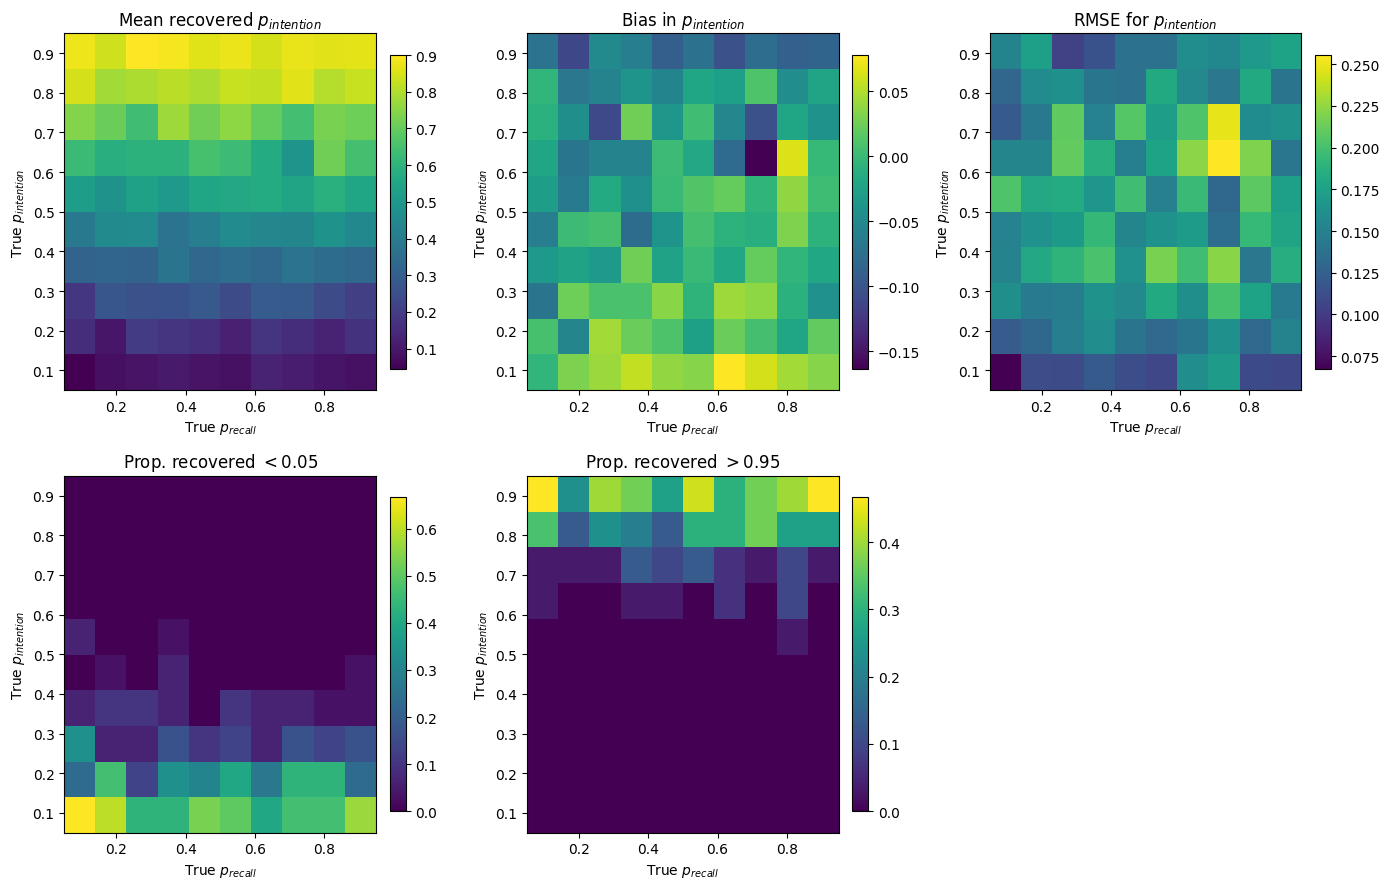

In [75]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

metrics_to_plot_int = [
    ("mean_est_p_intention", "Mean recovered $p_{intention}$"),
    ("bias_p_intention", "Bias in $p_{intention}$"),
    ("rmse_p_intention", "RMSE for $p_{intention}$"),
    ("prop_low_p_intention", "Prop. recovered $< 0.05$"),
    ("prop_high_p_intention", "Prop. recovered $> 0.95$"),
]

for ax, (col, title) in zip(axes.ravel(), metrics_to_plot_int):
    mat = make_heatmap_matrix(grid_summary_2p, col, p_int_grid, p_rec_grid)
    im = ax.imshow(
        mat,
        origin="lower",
        aspect="auto",
        extent=[p_rec_grid.min(), p_rec_grid.max(), p_int_grid.min(), p_int_grid.max()]
    )
    ax.set_title(title)
    ax.set_xlabel("True $p_{recall}$")
    ax.set_ylabel("True $p_{intention}$")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# turn off the unused 6th panel
axes.ravel()[-1].axis("off")

plt.tight_layout()
plt.show()

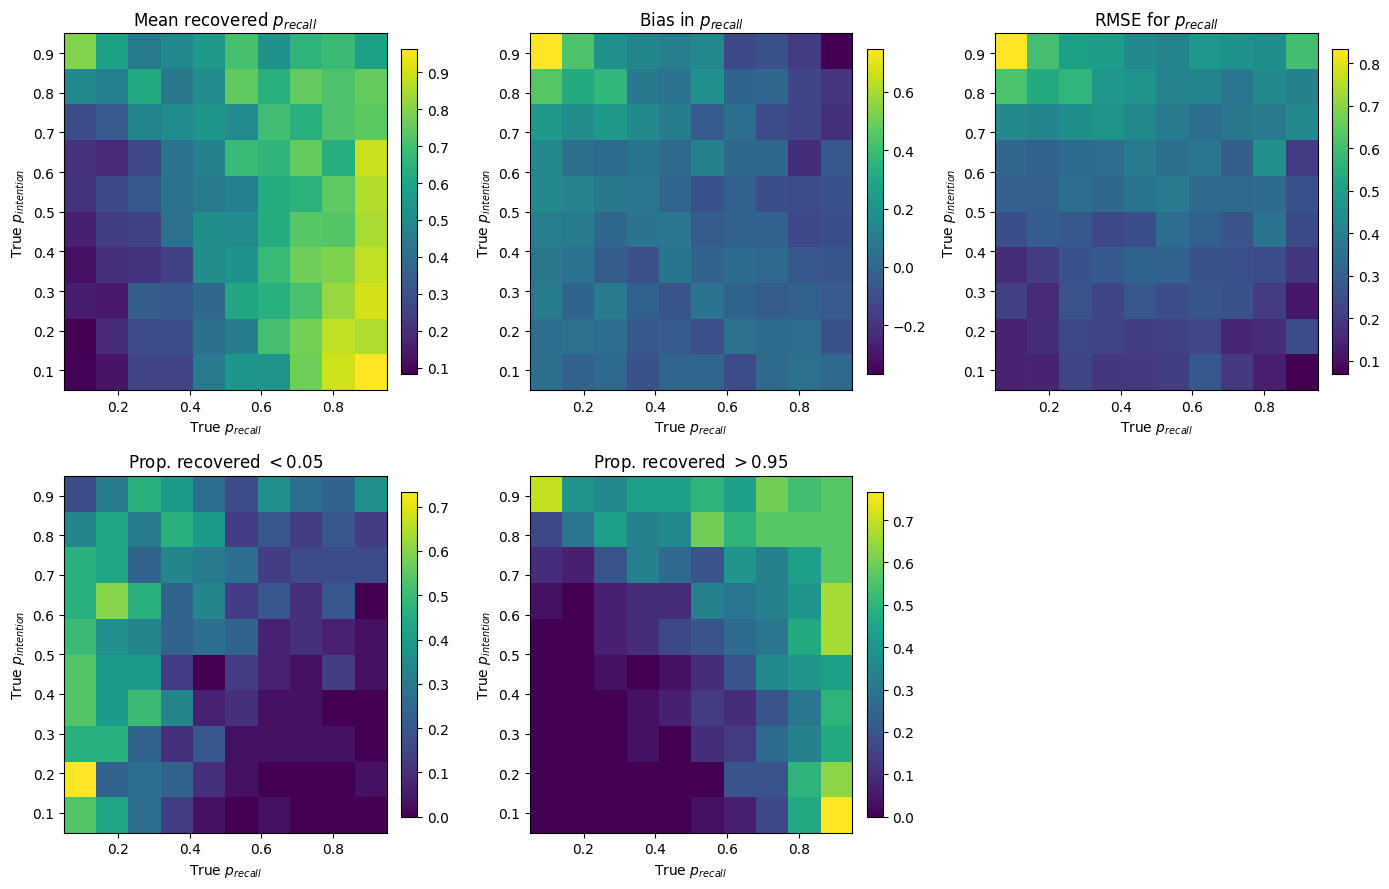

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

metrics_to_plot_rec = [
    ("mean_est_p_recall", "Mean recovered $p_{recall}$"),
    ("bias_p_recall", "Bias in $p_{recall}$"),
    ("rmse_p_recall", "RMSE for $p_{recall}$"),
    ("prop_low_p_recall", "Prop. recovered $< 0.05$"),
    ("prop_high_p_recall", "Prop. recovered $> 0.95$"),
]

for ax, (col, title) in zip(axes.ravel(), metrics_to_plot_rec):
    mat = make_heatmap_matrix(grid_summary_2p, col, p_int_grid, p_rec_grid)
    im = ax.imshow(
        mat,
        origin="lower",
        aspect="auto",
        extent=[p_rec_grid.min(), p_rec_grid.max(), p_int_grid.min(), p_int_grid.max()]
    )
    ax.set_title(title)
    ax.set_xlabel("True $p_{recall}$")
    ax.set_ylabel("True $p_{intention}$")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes.ravel()[-1].axis("off")

plt.tight_layout()
plt.show()

## Why recoverability can be non-symmetrical

Even in the 2-parameter model, the two latent quantities do not enter the likelihood in the same role.

The predicted accuracy has the form

$$
P(\text{correct})
=
p_{\text{intention}} \, P(\text{correct}\mid \text{proactive})
+
(1-p_{\text{intention}})
\Big[
p_{\text{recall}} \, P(\text{correct}\mid \text{recall})
+
(1-p_{\text{recall}})\, P(\text{correct}\mid \text{habit})
\Big].
$$

So:

- $p_{\text{intention}}$ controls how often behavior enters the **proactive** branch.
- $p_{\text{recall}}$ only acts **conditional on no intention**, within the remaining branch.

This means:

- $p_{\text{intention}}$ has a more direct global influence on the predicted AX / AY / BX / BY accuracies.
- $p_{\text{recall}}$ is effectively down-weighted by $(1-p_{\text{intention}})$.

As a result, when true intention is high, the recall branch is used less often, so the data carry less information about $p_{\text{recall}}$. This can make $p_{\text{intention}}$ recover better than $p_{\text{recall}}$, even though only two parameters are present.

### Check asymmetry of recoverability

- recovery of $p_{\text{recall}}$ looks better when true $p_{\text{intention}}$ is low to moderate,
- recovery of $p_{\text{intention}}$ looks relatively stable across true $p_{\text{recall}}$ values.

To test this, we summarize the grid by averaging over the other parameter axis:

- for $p_{\text{recall}}$ recovery, average RMSE / bias / boundary rates across true $p_{\text{recall}}$ at each fixed true $p_{\text{intention}}$;
- for $p_{\text{intention}}$ recovery, average RMSE / bias / boundary rates across true $p_{\text{intention}}$ at each fixed true $p_{\text{recall}}$.

This gives a direct 1D check of whether one parameter's recovery depends more strongly on the other parameter.

In [91]:
# Average over true p_recall to see how p_recall recovery changes with true p_intention
rec_by_int = (
    grid_summary_2p
    .groupby("true_p_intention", as_index=False)[
        ["rmse_p_recall", "bias_p_recall", "prop_low_p_recall", "prop_high_p_recall"]
    ]
    .mean()
)

# Average over true p_intention to see how p_intention recovery changes with true p_recall
int_by_rec = (
    grid_summary_2p
    .groupby("true_p_recall", as_index=False)[
        ["rmse_p_intention", "bias_p_intention", "prop_low_p_intention", "prop_high_p_intention"]
    ]
    .mean()
)

rec_by_int.head(), int_by_rec.head()

(   true_p_intention  rmse_p_recall  bias_p_recall  prop_low_p_recall  \
 0              0.05       0.178610      -0.010187           0.143333   
 1              0.15       0.200191      -0.006241           0.163333   
 2              0.25       0.224587       0.003119           0.160000   
 3              0.35       0.249354      -0.004018           0.200000   
 4              0.45       0.284132       0.003833           0.186667   
 
    prop_high_p_recall  
 0            0.150000  
 1            0.153333  
 2            0.133333  
 3            0.133333  
 4            0.156667  ,
    true_p_recall  rmse_p_intention  bias_p_intention  prop_low_p_intention  \
 0           0.05          0.141275         -0.029342              0.136667   
 1           0.15          0.154062         -0.037822              0.126667   
 2           0.25          0.163330         -0.021874              0.073333   
 3           0.35          0.159703         -0.013652              0.110000   
 4           0

These tables show whether recovery quality changes systematically along the other parameter axis.

In [92]:
display(rec_by_int.round(3))
display(int_by_rec.round(3))

,true_p_intention,rmse_p_recall,bias_p_recall,prop_low_p_recall,prop_high_p_recall
0,0.05,0.179,-0.010,0.143,0.150
1,0.15,0.200,-0.006,0.163,0.153
2,0.25,0.225,0.003,0.160,0.133
3,0.35,0.249,-0.004,0.200,0.133
4,0.45,0.284,0.004,0.187,0.157
5,0.55,0.328,0.002,0.220,0.223
6,0.65,0.337,0.016,0.273,0.233
7,0.75,0.411,0.045,0.267,0.290
8,0.85,0.469,0.113,0.273,0.440
9,0.95,0.527,0.103,0.300,0.497


,true_p_recall,rmse_p_intention,bias_p_intention,prop_low_p_intention,prop_high_p_intention
0,0.05,0.141,-0.029,0.137,0.087
1,0.15,0.154,-0.038,0.127,0.040
2,0.25,0.163,-0.022,0.073,0.067
3,0.35,0.160,-0.014,0.110,0.073
4,0.45,0.155,-0.016,0.093,0.053
5,0.55,0.162,-0.009,0.113,0.087
6,0.65,0.177,-0.012,0.080,0.073
7,0.75,0.183,-0.022,0.113,0.077
8,0.85,0.169,-0.001,0.107,0.090
9,0.95,0.156,-0.016,0.103,0.077


### Does $p_{\text{recall}}$ recovery worsen as true $p_{\text{intention}}$ increases?

If yes, RMSE and/or boundary-collapse rates for recovered $p_{\text{recall}}$ should rise as true $p_{\text{intention}}$ becomes high.

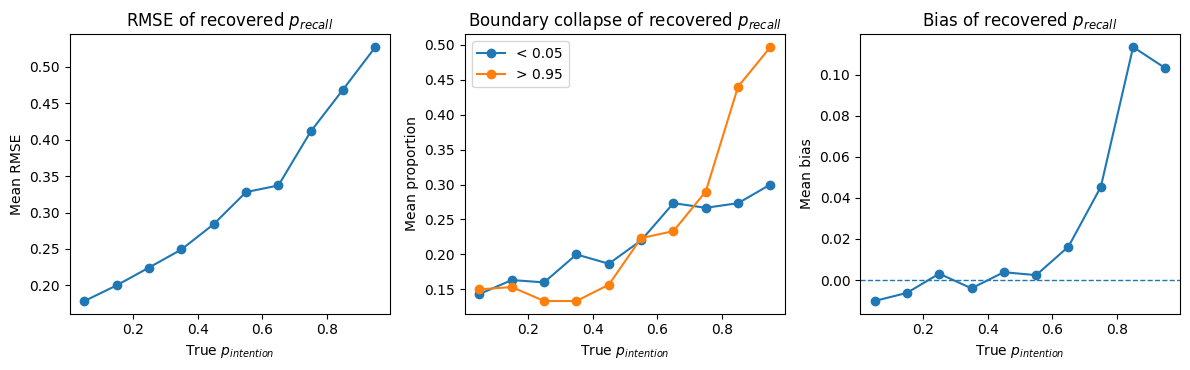

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

axes[0].plot(rec_by_int["true_p_intention"], rec_by_int["rmse_p_recall"], marker="o")
axes[0].set_title("RMSE of recovered $p_{recall}$")
axes[0].set_xlabel("True $p_{intention}$")
axes[0].set_ylabel("Mean RMSE")

axes[1].plot(rec_by_int["true_p_intention"], rec_by_int["prop_low_p_recall"], marker="o", label="< 0.05")
axes[1].plot(rec_by_int["true_p_intention"], rec_by_int["prop_high_p_recall"], marker="o", label="> 0.95")
axes[1].set_title("Boundary collapse of recovered $p_{recall}$")
axes[1].set_xlabel("True $p_{intention}$")
axes[1].set_ylabel("Mean proportion")
axes[1].legend()

axes[2].plot(rec_by_int["true_p_intention"], rec_by_int["bias_p_recall"], marker="o")
axes[2].axhline(0, linestyle="--", linewidth=1)
axes[2].set_title("Bias of recovered $p_{recall}$")
axes[2].set_xlabel("True $p_{intention}$")
axes[2].set_ylabel("Mean bias")

plt.tight_layout()
plt.show()

### Does $p_{\text{intention}}$ recovery stay stable across true $p_{\text{recall}}$?

If yes, RMSE and boundary-collapse rates for recovered $p_{\text{intention}}$ should change less across true $p_{\text{recall}}$ values.

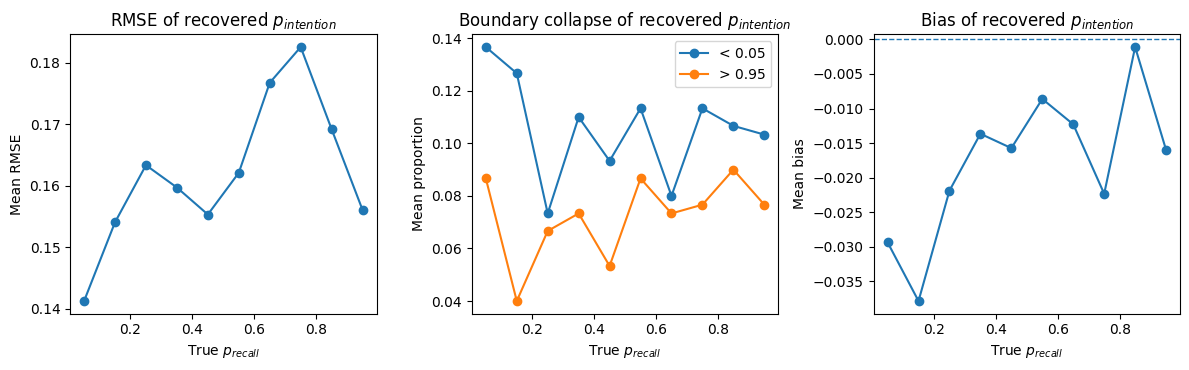

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

axes[0].plot(int_by_rec["true_p_recall"], int_by_rec["rmse_p_intention"], marker="o")
axes[0].set_title("RMSE of recovered $p_{intention}$")
axes[0].set_xlabel("True $p_{recall}$")
axes[0].set_ylabel("Mean RMSE")

axes[1].plot(int_by_rec["true_p_recall"], int_by_rec["prop_low_p_intention"], marker="o", label="< 0.05")
axes[1].plot(int_by_rec["true_p_recall"], int_by_rec["prop_high_p_intention"], marker="o", label="> 0.95")
axes[1].set_title("Boundary collapse of recovered $p_{intention}$")
axes[1].set_xlabel("True $p_{recall}$")
axes[1].set_ylabel("Mean proportion")
axes[1].legend()

axes[2].plot(int_by_rec["true_p_recall"], int_by_rec["bias_p_intention"], marker="o")
axes[2].axhline(0, linestyle="--", linewidth=1)
axes[2].set_title("Bias of recovered $p_{intention}$")
axes[2].set_xlabel("True $p_{recall}$")
axes[2].set_ylabel("Mean bias")

plt.tight_layout()
plt.show()

## Quantitative check

Summarize the monotonic trend with simple correlations:

- between true $p_{\text{intention}}$ and mean RMSE of recovered $p_{\text{recall}}$,
- between true $p_{\text{recall}}$ and mean RMSE of recovered $p_{\text{intention}}$.

In [95]:
corr_rec_rmse_vs_int = np.corrcoef(
    rec_by_int["true_p_intention"],
    rec_by_int["rmse_p_recall"]
)[0, 1]

corr_int_rmse_vs_rec = np.corrcoef(
    int_by_rec["true_p_recall"],
    int_by_rec["rmse_p_intention"]
)[0, 1]

corr_rec_low_vs_int = np.corrcoef(
    rec_by_int["true_p_intention"],
    rec_by_int["prop_low_p_recall"] + rec_by_int["prop_high_p_recall"]
)[0, 1]

corr_int_low_vs_rec = np.corrcoef(
    int_by_rec["true_p_recall"],
    int_by_rec["prop_low_p_intention"] + int_by_rec["prop_high_p_intention"]
)[0, 1]

pd.Series({
    "corr(true p_intention, RMSE of recovered p_recall)": corr_rec_rmse_vs_int,
    "corr(true p_recall, RMSE of recovered p_intention)": corr_int_rmse_vs_rec,
    "corr(true p_intention, boundary rate of recovered p_recall)": corr_rec_low_vs_int,
    "corr(true p_recall, boundary rate of recovered p_intention)": corr_int_low_vs_rec,
}).round(3)

corr(true p_intention, RMSE of recovered p_recall)             0.980
corr(true p_recall, RMSE of recovered p_intention)             0.607
corr(true p_intention, boundary rate of recovered p_recall)    0.937
corr(true p_recall, boundary rate of recovered p_intention)    0.023
dtype: float64

### Comparison: moderate vs high true $p_{\text{intention}}$

In [96]:
threshold = 0.7

tmp = grid_summary_2p.copy()
tmp["intention_region"] = np.where(tmp["true_p_intention"] <= threshold, "low_to_moderate", "high")

region_summary = (
    tmp.groupby("intention_region")[["rmse_p_recall", "bias_p_recall", "prop_low_p_recall", "prop_high_p_recall"]]
    .mean()
    .round(3)
)

region_summary

,rmse_p_recall,bias_p_recall,prop_low_p_recall,prop_high_p_recall
intention_region,,,,
high,0.469,0.087,0.280,0.409
low_to_moderate,0.257,0.001,0.192,0.169


> Once intention gets high, the recall branch is used less, and $p_{\text{recall}}$ becomes harder to estimate reliably from AX/AY/BX/BY summary counts.